# Gaia Be Star → Roman Time Sampling Pipeline

This notebook demonstrates the end-to-end pipeline for predicting what a **Be star outburst** observed by Gaia (G-band) would look like on the **Nancy Grace Roman Space Telescope** cadence.

**Pipeline overview:**
1. Load a Gaia Be star light curve (G-band CSV)
2. Compress large observing gaps and rescale the time axis
3. Bin data and fit a Gaussian Process to the binned photometry
4. Extend the GP model to a 2000-day window and select the best Roman sub-window
5. Evaluate the GP at Roman short- and long-cadence timestamps to produce synthetic light curves

**Key difference from the GP-fit demo:** this notebook focuses on *time-domain transfer* — using the fitted GP as a generative model to produce Roman-cadence light curves rather than evaluating GP fit quality on the Gaia grid.

In [32]:
import pickle as pkl
import re
from pathlib import Path
from glob import glob
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d
from scipy.signal import find_peaks
from astropy.io import fits
from astropy.table import Table
import george
from george import kernels
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import AutoMinorLocator
from matplotlib.patches import FancyArrowPatch
from functions import (
    read_fits, prep_input, prep_gp, fit_gp,
    binning_data, multiscale_peaks, predict_gp,
    get_metrics, l2_distance, find_valid_rows
)
from gp_model_params import info
from tqdm.notebook import tqdm
np.random.seed(42)

In [33]:
# Global matplotlib style for paper figures
plt.rcParams.update({
    "font.family"      : "serif",
    "font.size"        : 13,
    "axes.labelsize"   : 14,
    "axes.titlesize"   : 14,
    "legend.fontsize"  : 11,
    "xtick.direction"  : "in",
    "ytick.direction"  : "in",
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "figure.dpi"       : 120,
})

# Colour palette (colour-blind friendly)
C0, C1, C2, C3, C4 = "#0072B2", "#E69F00", "#009E73", "#D55E00", "#CC79A7"

In [34]:
# Paths and source-type configuration
home = str(Path.home())

TP   = 'Be'
BAND = 'G'        # Gaia G-band

DATA_PATH   = home + '/Research_data/GAIA BE stars/Gaia_Be_stars_candidates/gaia_science_alerts_be_stars_lightcurves/'
OUTPUT_PLOT = f'output/plots/{TP}/'
OUTPUT_FILE = 'output/'

Path(OUTPUT_PLOT).mkdir(parents=True, exist_ok=True)
Path(OUTPUT_FILE).mkdir(parents=True, exist_ok=True)

# Be stars are non-periodic — period is set to NaN throughout
period = np.nan

## Load Roman Telescope Cadence Arrays

In [4]:
# Load pre-computed Roman Galactic Bulge cadence time arrays
Roman_sampling_short  = np.load('lc_example/roman_times_shortcadence.npy')
Roman_sampling_long   = np.load('lc_example/roman_times_longcadence.npy')
Roman_sampling_long2  = np.load('lc_example/roman_times_longcadence2.npy')


Roman_sampling_long   -= Roman_sampling_long.min()
Roman_sampling_long2  -= Roman_sampling_short.min()
Roman_sampling_short  -= Roman_sampling_short.min()

Roman_max_short_time = Roman_sampling_short.max()

t_base       = Roman_sampling_short
t_base_long  = Roman_sampling_long
t_base_long2 = Roman_sampling_long2

# Dense regular grid for smooth curve evaluation
t_regular = np.linspace(0, Roman_max_short_time, 750_000)

print(f"Short cadence  : {len(t_base):,} pts  |  span = {Roman_max_short_time:.1f} d")
print(f"Long cadence 1 : {len(t_base_long):,} pts  |  span = {t_base_long.max():.1f} d")
print(f"Long cadence 2 : {len(t_base_long2):,} pts  |  span = {t_base_long2.max():.1f} d")

Short cadence  : 50,700 pts  |  span = 982.0 d
Long cadence 1 : 1,704 pts  |  span = 981.8 d
Long cadence 2 : 1,704 pts  |  span = 981.9 d


## Load a Single Gaia Be Star Light Curve

Gaia Science Alerts provides G-band photometry for transient events including Be star outbursts. Each source is stored as a CSV with columns `JD(TCB)`, `mag`, and `err`.

In [35]:
# Discover all available light curve CSVs
lc_list = sorted(glob(DATA_PATH + '*.csv'))
print(f"Found {len(lc_list)} light curve files.")

# Select a single demo source
demo_path = lc_list[0]
demo_id   = Path(demo_path).stem
print(f"Demo source   : {demo_id}")

Found 270 light curve files.
Demo source   : Gaia18dek


In [36]:
# Read CSV and rename columns to pipeline convention
loaded_df = pd.read_csv(demo_path).reset_index(drop=True)
df        = loaded_df.rename(columns={"JD(TCB)": "t", "mag": "m", "err": "e"})

print(f"G-band : {len(df):,} points  "
      f"| t ∈ [{df.t.min():.1f}, {df.t.max():.1f}] JD days  "
      f"| <m> = {df.m.mean():.3f}")
df.head()

G-band : 222 points  | t ∈ [2456865.2, 2460309.4] JD days  | <m> = 17.535


,t,m,e
0,2.456865e+06,17.66,0.021459
1,2.456865e+06,17.63,0.021077
2,2.456866e+06,17.64,0.021203
3,2.456866e+06,17.64,0.021203
4,2.456866e+06,17.64,0.021203


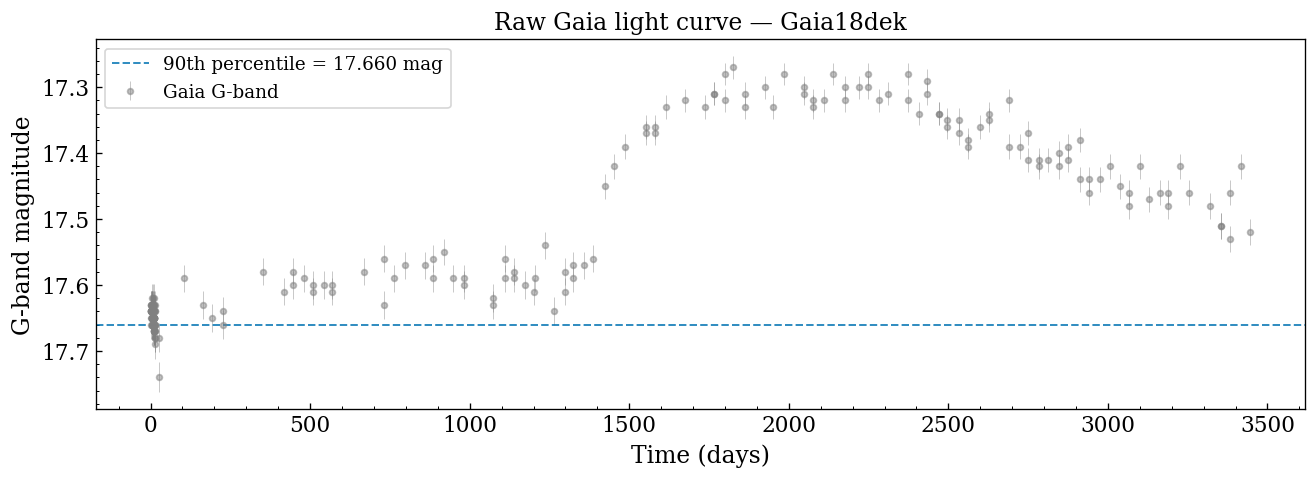

In [39]:
# Raw Gaia G-band light curve

fig, ax = plt.subplots(figsize=(13, 4))

ax.errorbar(df.t-np.min(df.t), df.m, yerr=df.e, fmt='.', color='grey',
            alpha=0.5, ms=7, lw=0.5, label='Gaia G-band', zorder=2)
ax.axhline(np.percentile(df.m, 90), color=C0, lw=1.2, ls='--',
           alpha=0.8, label=f'90th percentile = {np.percentile(df.m, 90):.3f} mag')

ax.invert_yaxis()
ax.set_xlabel('Time (days)')
ax.set_ylabel('G-band magnitude')
ax.set_title(f'Raw Gaia light curve — {demo_id}')
ax.legend()
ax.xaxis.set_minor_locator(AutoMinorLocator())

## Preprocessing

In [40]:
# Normalise time axis
if df.t.min() > 0:
    df['t'] = df['t'] - df['t'].min()

In [43]:
# Compress observing gaps > 500 days

inds  = np.where(np.diff(df.t.values) > 500)[0]
t_min = np.min(np.diff(df.t.values))

df_modified = df.copy()
for ind in inds:
    time_gap = df_modified.t.iloc[ind + 1] - df_modified.t.iloc[ind] + t_min
    df_modified.loc[df_modified.index[ind + 1]:, 't'] -= time_gap

print(f"Gaps compressed : {len(inds)} gap(s) removed")
print(f"Baseline span   : {df.t.max():.1f} d  →  {df_modified.t.max():.1f} d")

Gaps compressed : 0 gap(s) removed
Baseline span   : 3444.2 d  →  3444.2 d


In [44]:
# Rescale time axis by scale factor so the scaled time axis be between 0 and 5

df_modified = df_modified.copy()
scale_factor = np.max(df_modified['t'])/5
df_modified['t'] = df_modified['t']/scale_factor

print(f"Time axis after rescaling: [{df_modified.t.min():.4f}, {df_modified.t.max():.4f}]  (× {scale_factor:.2f} = days)")

Time axis after rescaling: [0.0000, 5.0000]  (× 688.84 = days)


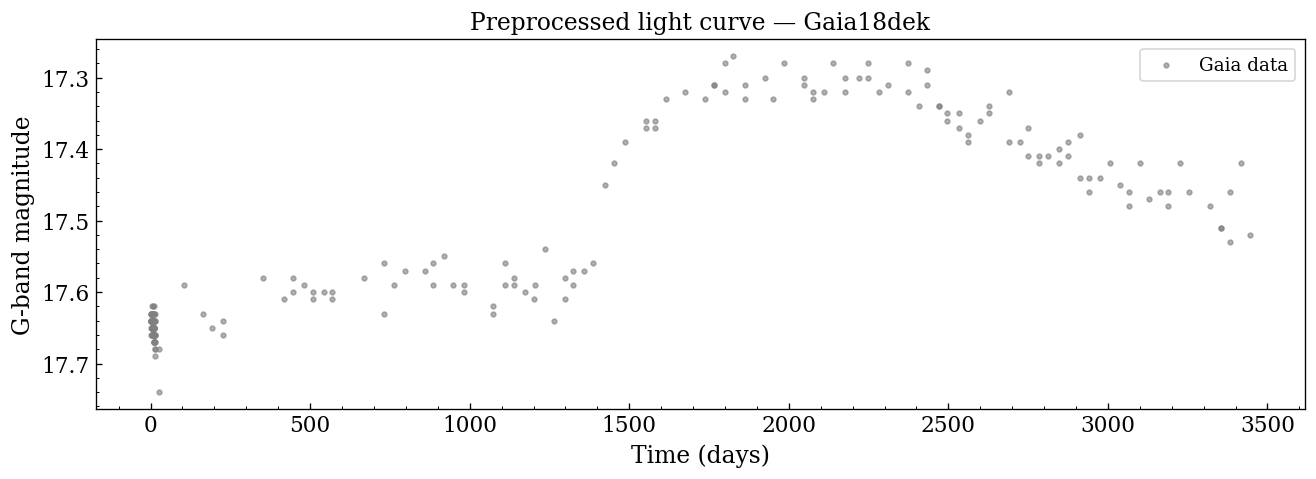

In [46]:
# Preprocessed light curve
fig, ax = plt.subplots(figsize=(13, 4))

ax.scatter(df_modified.t * scale_factor, df_modified.m, s=8, alpha=0.6,
           color='grey', label='Gaia data')

ax.invert_yaxis()
ax.set_xlabel('Time (days)')
ax.set_ylabel('G-band magnitude')
ax.set_title(f'Preprocessed light curve — {demo_id}')
ax.legend()
ax.xaxis.set_minor_locator(AutoMinorLocator())

## GP Preparation and Binning

In [47]:
# Initialise GP and build multi-phase input array
gp = prep_gp(info[TP], period)

x, y, e = prep_input(df_modified, TP, period, info[TP], Roman_max_short_time)

In [48]:
# Bin the data to reduce GP matrix size

if len(x) > 100:
    info[TP]['fit_binned'] = True
    x_binned, y_binned, e_binned, regular_sampling_fit = binning_data(
        x, y, e, info[TP], n_bins=100
    )
else:
    info[TP]['fit_binned'] = False
    x_binned, y_binned, e_binned, regular_sampling_fit = binning_data(
        x, y, e, info[TP], n_bins=np.nan
    )

# Drop bins whose error estimate is NaN (empty bins at the edges)
valid    = ~np.isnan(e_binned)
x_binned = x_binned[valid]
y_binned = y_binned[valid]
e_binned = e_binned[valid]

y_median = np.percentile(y, 90)   # use 90th-percentile as baseline (faintest typical flux)

print(f"Binned size : {len(x_binned)} points  (from {len(x)} raw)")
print(f"y_median    : {y_median:.4f} mag")

Binned size : 83 points  (from 222 raw)
y_median    : 17.6600 mag


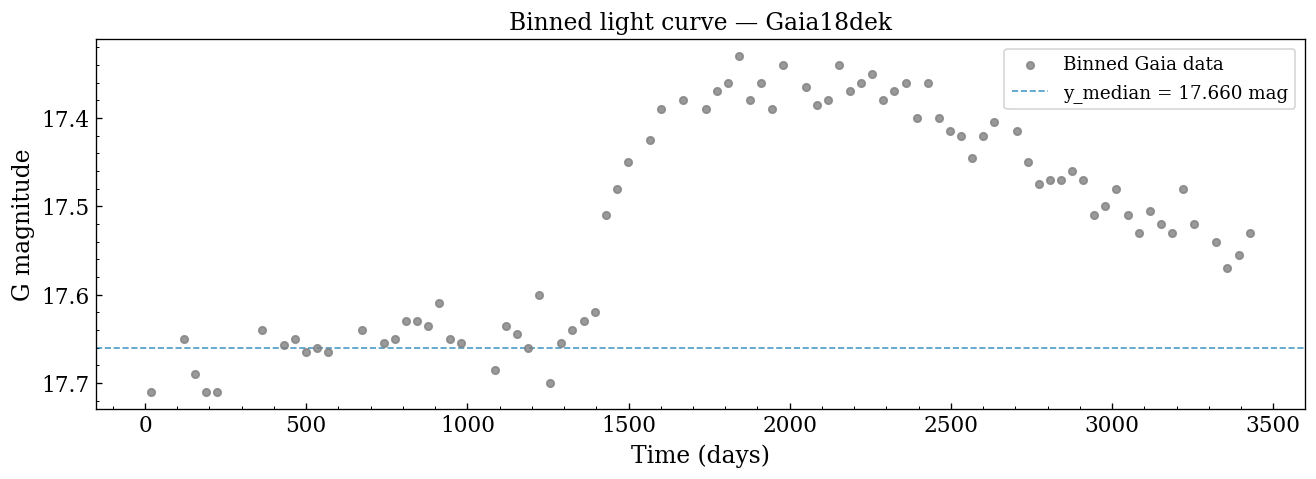

In [54]:
# Binned light curve
fig, ax = plt.subplots(figsize=(13, 4))

ax.scatter(x_binned * scale_factor, y_binned + y_median, s=20, alpha=0.8,
           color='grey', zorder=3, label='Binned Gaia data')
ax.axhline(y_median, color=C0, lw=1.0, ls='--', alpha=0.7,
           label=f'y_median = {y_median:.3f} mag')

ax.invert_yaxis()
ax.set_xlabel('Time (days)')
ax.set_ylabel('G magnitude')
ax.set_title(f'Binned light curve — {demo_id}')
ax.legend()
ax.xaxis.set_minor_locator(AutoMinorLocator())

## GP Fitting

In [55]:
# Fit GP to the binned data
import time

t0 = time.time()
gp = fit_gp(x_binned, y_binned, e_binned, info[TP], gp)
print(f"GP fit complete in {time.time() - t0:.1f} s")
print(f"Kernel params  : {gp.kernel.parameter_vector}")

GP fit complete in 0.3 s
Kernel params  : [-3.87025697 -0.48150696]


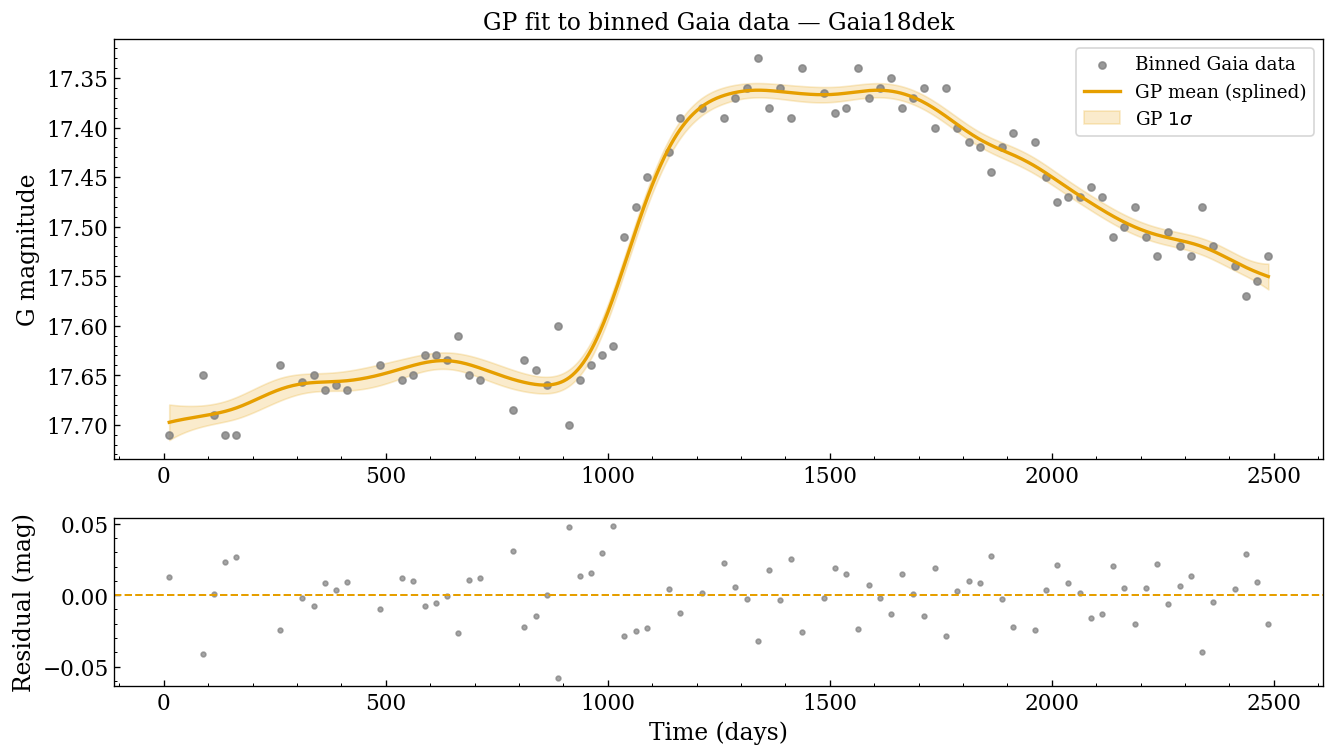

In [57]:
# GP mean evaluated at binned data points

from scipy.interpolate import CubicSpline

gp_y_binned_fit, cov_binned = gp.predict(y_binned, x_binned, return_cov=True)
gp_std_binned               = np.sqrt(np.diag(cov_binned))

# Build smooth display curve via spline (avoids dense-grid GP ringing)
sort_idx      = np.argsort(x_binned)
cs_fit        = CubicSpline(x_binned[sort_idx], gp_y_binned_fit[sort_idx])
cs_std        = CubicSpline(x_binned[sort_idx], gp_std_binned[sort_idx])
x_display     = np.linspace(x_binned.min(), x_binned.max(), 800)
y_display     = cs_fit(x_display)
std_display   = np.abs(cs_std(x_display))

fig, axes = plt.subplots(2, 1, figsize=(13, 7),
                         gridspec_kw={'height_ratios': [2.5, 1]})

ax = axes[0]
ax.scatter(x_binned * 500, y_binned + y_median,
           s=18, alpha=0.8, color='grey', zorder=3, label='Binned Gaia data')
ax.plot(x_display * 500, y_display + y_median,
        color=C1, lw=2.0, zorder=4, label='GP mean (splined)')
ax.fill_between(x_display * 500,
                y_display + y_median - std_display,
                y_display + y_median + std_display,
                color=C1, alpha=0.2, label=r'GP $1\sigma$')
ax.invert_yaxis()
ax.set_ylabel('G magnitude')
ax.set_title(f'GP fit to binned Gaia data — {demo_id}')
ax.legend()
ax.xaxis.set_minor_locator(AutoMinorLocator())

# Residuals
resid = y_binned - gp_y_binned_fit
axes[1].scatter(x_binned * 500, resid, s=8, alpha=0.7, color='grey')
axes[1].axhline(0, color=C1, lw=1.2, ls='--')
axes[1].set_xlabel('Time (days)')
axes[1].set_ylabel('Residual (mag)')
axes[1].xaxis.set_minor_locator(AutoMinorLocator())


## Roman Resampling via Random Injection of the Be outburst

Outburst rise detected at t = 1395 days
Outburst peak detected at t = 1843 days


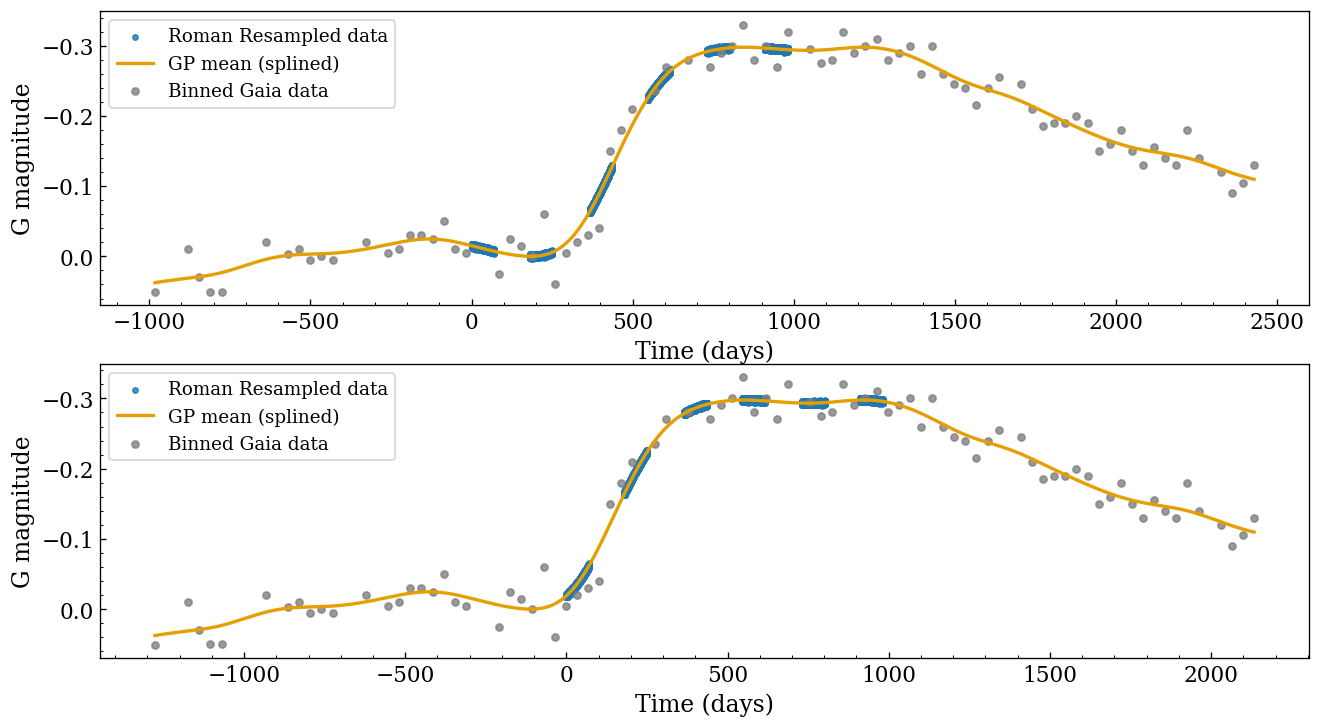

In [60]:
n_lc = 1

baseline_mag = max(y_binned + y_median)
dy       = np.diff(y_binned)           # smoothed_y is inverted (mag), so a rise = negative diff
dy_std   = np.std(dy)
dy_mean  = np.mean(dy)

# A brightening = magnitude drops = dy is negative; find first point > 3σ below mean
rise_idx = np.where(dy < dy_mean - 3 * dy_std)[0][0]
t_rise   = x_binned[rise_idx] * scale_factor
t_peak = x_binned[np.argmin(y_binned)] * scale_factor
print(f"Outburst rise detected at t = {t_rise:.0f} days")
print(f"Outburst peak detected at t = {t_peak:.0f} days")

t_offset = 100
t_base_exc_edge = t_base[(t_base<np.max(t_base)-t_offset) & (t_base>np.min(t_base)+t_offset)]
t_rise_all = np.random.choice(t_base_exc_edge, size=n_lc)
t_peak_all = np.random.choice(t_base_exc_edge, size=n_lc)

y_base = np.ones_like(t_base) * baseline_mag + np.random.normal(0, 0.001, size=len(t_base))
y_base_long = np.ones_like(t_base_long) * baseline_mag + np.random.normal(0, 0.001, size=len(t_base_long))
y_base_long2 = np.ones_like(t_base_long2) * baseline_mag + np.random.normal(0, 0.001, size=len(t_base_long2))
y_base_regular = np.ones_like(t_regular) * baseline_mag + np.random.normal(0, 0.001, size=len(t_regular))

y_median_base = np.median(y_base)
y_base = y_base - y_median_base
y_base_long = y_base_long - y_median_base
y_base_long2 = y_base_long2 - y_median_base
y_base_regular = y_base_regular - y_median_base



counter = 0
for i, t_p, t_r  in zip(range(n_lc), t_peak_all, t_rise_all):


    y_sim = y_base.copy()
    y_sim_long = y_base_long.copy()
    y_sim_long2 = y_base_long2.copy()
    y_sim_regular = y_base_regular.copy()

    y_sim_p = y_base.copy()
    y_sim_long_p = y_base_long.copy()
    y_sim_long2_p = y_base_long2.copy()
    y_sim_regular_p = y_base_regular.copy()

    
    counter += 1
    
    x_binned_mod = x_binned *scale_factor + (t_r-t_rise)
    x_binned_mod_p = x_binned *scale_factor + (t_p-t_peak)
    
    t_min = max(np.min(t_base), np.min(x_binned_mod))
    t_max = min(np.max(t_base), np.max(x_binned_mod))
    mask = (t_base >= t_min) & (t_base <= t_max)
    
    
    if np.sum(mask)!=0:
        t_local = t_base[mask] - (t_r-t_rise)
        outburst_mag = cs_fit(t_local/scale_factor)
        y_sim[mask] += outburst_mag+(y_median-y_median_base)

    t_min = max(np.min(t_regular), np.min(x_binned_mod))
    t_max = min(np.max(t_regular), np.max(x_binned_mod))
    mask_regular = (t_regular >= t_min) & (t_regular <= t_max)
    
    if np.sum(mask_regular)!=0:
        t_local = t_regular[mask_regular] - (t_r-t_rise)
        outburst_mag = cs_fit(t_local/scale_factor)
        y_sim_regular[mask_regular] += outburst_mag+(y_median-y_median_base)

    t_min = max(np.min(t_base_long), np.min(x_binned_mod))
    t_max = min(np.max(t_base_long), np.max(x_binned_mod))
    mask_long = (t_base_long >= t_min) & (t_base_long <= t_max)
    
    if np.sum(mask_long)!=0:
        t_local = t_base_long[mask_long] - (t_r-t_rise)
        outburst_mag = cs_fit(t_local/scale_factor)
        y_sim_long[mask_long] += outburst_mag+(y_median-y_median_base)

    t_min = max(np.min(t_base_long2), np.min(x_binned_mod))
    t_max = min(np.max(t_base_long2), np.max(x_binned_mod))
    mask_long2 = (t_base_long2 >= t_min) & (t_base_long2 <= t_max)
    
    if np.sum(mask_long2)!=0:
        t_local = t_base_long2[mask_long2] - (t_r-t_rise)
        outburst_mag = cs_fit(t_local/scale_factor)
        y_sim_long2[mask_long2] += outburst_mag+(y_median-y_median_base)



    # --------------------------------------------------------

    t_min_p = max(np.min(t_base), np.min(x_binned_mod_p))
    t_max_p = min(np.max(t_base), np.max(x_binned_mod_p))
    mask_p = (t_base >= t_min_p) & (t_base <= t_max_p)
    
    
    if np.sum(mask_p)!=0:
        t_local = t_base[mask_p] - (t_p-t_peak)
        outburst_mag = cs_fit(t_local/scale_factor)
        y_sim_p[mask_p] += outburst_mag+(y_median-y_median_base)

    t_min_p = max(np.min(t_regular), np.min(x_binned_mod_p))
    t_max_p = min(np.max(t_regular), np.max(x_binned_mod_p))
    mask_regular_p = (t_regular >= t_min_p) & (t_regular <= t_max_p)
    
    if np.sum(mask_regular_p)!=0:
        t_local = t_regular[mask_regular_p] - (t_p-t_peak)
        outburst_mag = cs_fit(t_local/scale_factor)
        y_sim_regular_p[mask_regular_p] += outburst_mag+(y_median-y_median_base)

    t_min_p = max(np.min(t_base_long), np.min(x_binned_mod_p))
    t_max_p = min(np.max(t_base_long), np.max(x_binned_mod_p))
    mask_long_p = (t_base_long >= t_min_p) & (t_base_long <= t_max_p)
    
    if np.sum(mask_long_p)!=0:
        t_local = t_base_long[mask_long_p] - (t_p-t_peak)
        outburst_mag = cs_fit(t_local/scale_factor)
        y_sim_long_p[mask_long_p] += outburst_mag+(y_median-y_median_base)

    t_min_p = max(np.min(t_base_long2), np.min(x_binned_mod_p))
    t_max_p = min(np.max(t_base_long2), np.max(x_binned_mod_p))
    mask_long2_p = (t_base_long2 >= t_min_p) & (t_base_long2 <= t_max_p)
    
    if np.sum(mask_long2_p)!=0:
        t_local = t_base_long2[mask_long2_p] - (t_p-t_peak)
        outburst_mag = cs_fit(t_local/scale_factor)
        y_sim_long2_p[mask_long2_p] += outburst_mag+(y_median-y_median_base)


    fig, ax = plt.subplots(2, 1, figsize= (13, 7))
    ax[0].scatter(t_base, y_sim+y_median_base-y_median,
                s=10, alpha=0.8, color='C0', zorder=3, label='Roman Resampled data')
    ax[0].plot(x_display * scale_factor + (t_r-t_rise), y_display,
            color=C1, lw=2.0, zorder=4, label='GP mean (splined)')
    ax[0].scatter(x_binned * scale_factor+ (t_r-t_rise), y_binned,
               s=18, alpha=0.8, color='grey', zorder=3, label='Binned Gaia data')
    # plt.axvline(t_rise)
    # plt.axvline(t_min)
    # plt.axvline(t_max)
    
    ax[0].invert_yaxis()
    ax[0].legend()
    ax[0].set_xlabel('Time (days)')
    ax[0].set_ylabel('G magnitude')
    ax[0].xaxis.set_minor_locator(AutoMinorLocator())

    ax[1].scatter(t_base, y_sim_p+y_median_base-y_median,
                s=10, alpha=0.8, color='C0', zorder=3, label='Roman Resampled data')
    ax[1].plot(x_display * scale_factor + (t_p-t_peak), y_display,
            color=C1, lw=2.0, zorder=4, label='GP mean (splined)')
    ax[1].scatter(x_binned * scale_factor+ (t_p-t_peak), y_binned,
               s=18, alpha=0.8, color='grey', zorder=3, label='Binned Gaia data')
    # plt.axvline(t_rise)
    # plt.axvline(t_min)
    # plt.axvline(t_max)
    
    ax[1].invert_yaxis()
    ax[1].legend()
    ax[1].set_xlabel('Time (days)')
    ax[1].set_ylabel('G magnitude')
    ax[1].xaxis.set_minor_locator(AutoMinorLocator())